# **Phishing Website Detection by Machine Learning Techniques**

*Final project of AI & Cybersecurity Course*

## **1. Objective:**
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to train machine learning models and deep neural nets on the dataset created to predict phishing websites. Both phishing and benign URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measures and compared.

*This project is worked on Google Collaboratory.*<br>
*The required packages for this notebook are imported when needed.*

## **2. Loading Data:**

The features are extracted and store in the csv file. The working of this can be seen in the 'Phishing Website Detection_Feature Extraction.ipynb' file.

The reulted csv file is uploaded to this notebook and stored in the dataframe.

In [ ]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
#Loading the data
data0 = pd.read_csv('5.urldata.csv')
data0.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


# 2. Data Inspection *

In this section, we inspect the dataset to understand its structure, dimensions, feature types, index, missing values, duplicated rows, and overall data quality before applying preprocessing and machine learning models.

In [18]:
# Dataset Shape
print("Dataset Shape:")
print(data0.shape)

print("\n----------------------")

# Dataset Information
print("Dataset Information:")
data0.info()

print("\n----------------------")

# Data Types
print("Data Types:")
print(data0.dtypes)

print("\n----------------------")

# Column Names
print("Column Names:")
print(data0.columns)

print("\n----------------------")

# Index Information
print("Index:")
print(data0.index)

print("\n----------------------")

# Missing Values
print("Missing Values:")
print(data0.isnull().sum())

print("\n----------------------")

# Duplicate Rows
print("Duplicate Rows:")
print(data0.duplicated().sum())

Dataset Shape:
(10000, 18)

----------------------
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17

In [19]:
# Check duplicate rows

duplicates = data0[data0.duplicated()]

print("Number of duplicate rows:", duplicates.shape[0])

duplicates.head()

Number of duplicate rows: 5626


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
14,thenextweb.com,0,0,1,6,0,0,0,0,0,1,0,0,0,0,1,0,0
19,allegro.pl,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,1,0
28,mic.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
30,emgn.com,0,0,1,2,0,0,0,0,0,1,0,0,1,1,1,1,0
35,nypost.com,0,0,1,4,0,0,1,0,0,1,1,1,0,0,1,0,0


In [20]:
# Show all duplicated rows (including the first occurrence)
data0[data0.duplicated(keep=False)].sort_values(by="Domain").head(20)

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
5746,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8142,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8770,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8084,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
9876,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
4868,1337x.to,0,0,1,3,0,0,0,0,0,1,1,1,0,0,1,0,0
1993,1337x.to,0,0,1,3,0,0,0,0,0,1,1,1,0,0,1,0,0
4137,1337x.to,0,0,1,3,0,0,0,0,1,1,1,1,0,0,1,0,0
2767,1337x.to,0,0,1,3,0,0,0,0,1,1,1,1,0,0,1,0,0
2312,1337x.to,0,0,1,3,0,0,0,0,0,1,1,1,0,0,1,0,0


In [21]:
# Check rows that are duplicated in ALL columns

duplicates_all = data0[data0.duplicated(keep=False)]

duplicates_all.sort_values(by="Domain")

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
5746,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8142,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8770,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8084,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
9876,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3226,zozo.jp,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,0,0
206,zozo.jp,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,0,0
4213,zozo.jp,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,0,0
2870,zozo.jp,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,0,0


In [22]:
print("Original dataset:", data0.shape)

data_no_duplicates = data0.drop_duplicates()

print("Without duplicates:", data_no_duplicates.shape)

Original dataset: (10000, 18)
Without duplicates: (4374, 18)


In [23]:
# Class Distribution

print(data0["Label"].value_counts())

print()

print(data0["Label"].value_counts(normalize=True) * 100)

Label
0    5000
1    5000
Name: count, dtype: int64

Label
0    50.0
1    50.0
Name: proportion, dtype: float64


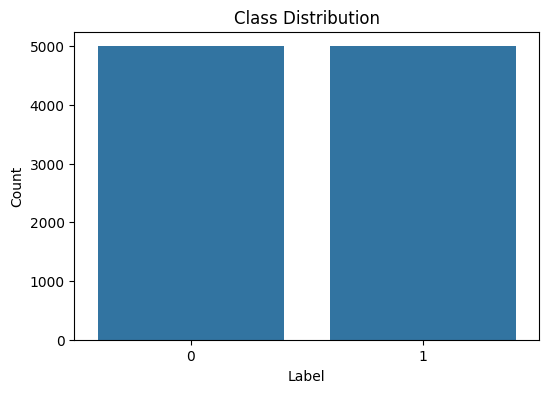

In [24]:
# Visualizing class distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Label", data=data0)

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

### Class Imbalance Analysis    *

<font color="red">The dataset is perfectly balanced, containing 5,000 legitimate websites (Label = 0) and 5,000 phishing websites (Label = 1). Therefore, there is no class imbalance problem.

<font color="red">A balanced dataset is beneficial because the machine learning models are less likely to become biased toward one class. This makes evaluation metrics such as Accuracy more meaningful. However, additional metrics such as Precision, Recall, F1-score, ROC-AUC, and MCC are still required to provide a complete evaluation of the models.

## Outlier Analysis *

<font color="red">Outlier analysis helps identify observations that differ significantly from the majority of the data. Detecting outliers is important because they may represent data errors, unusual behavior, or rare but meaningful cybersecurity cases.

<font color="red">Since most features in this dataset are binary (0 or 1), outlier analysis is mainly relevant for numerical features such as URL_Depth.

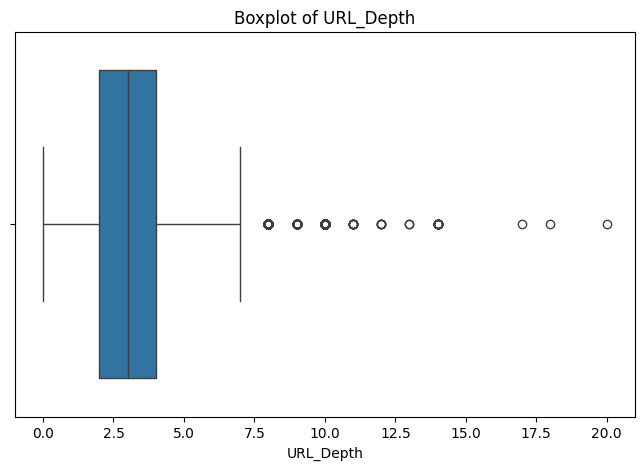

In [25]:
# Boxplot for URL_Depth

plt.figure(figsize=(8,5))
sns.boxplot(x=data0["URL_Depth"])

plt.title("Boxplot of URL_Depth")
plt.show()

### Outlier Analysis *

<font color="red">The boxplot indicates the presence of several outliers in the **URL_Depth** feature. Most websites have a relatively small URL depth, while a few websites have significantly deeper URLs.

<font color="red">These outliers were not removed because, in cybersecurity, unusually deep URLs may represent suspicious or phishing websites rather than data errors. Therefore, retaining these observations preserves potentially valuable information for the machine learning models.

## **3. Familiarizing with Data**
In this step, few dataframe methods are used to look into the data and its features.

In [ ]:
#Checking the shape of the dataset
data0.shape

(10000, 18)

In [ ]:
#Listing the features of the dataset
data0.columns

Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')

In [ ]:
#Information about the dataset
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

## **4. Visualizing the data**
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

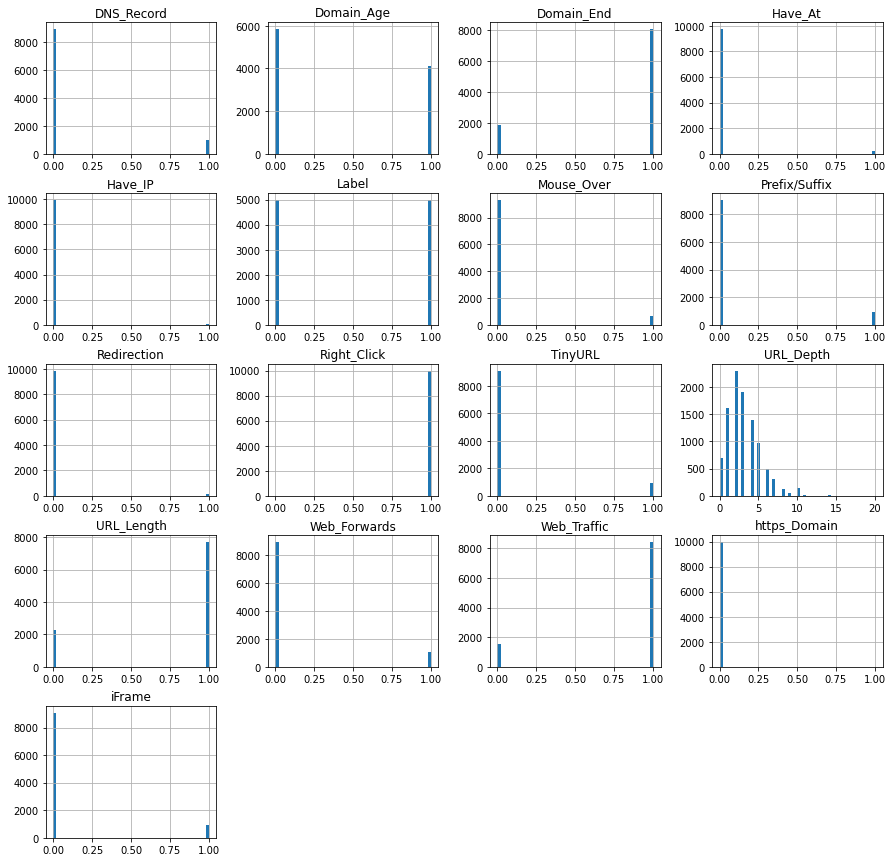

In [ ]:
#Plotting the data distribution
data0.hist(bins = 50,figsize = (15,15))
plt.show()

## Correlation Analysis *

<font color="red">Correlation analysis helps identify relationships between features. Since most variables in this dataset are numerical (binary 0/1 or integer values), the Pearson correlation coefficient was selected.

<font color="red">Pearson correlation measures the strength and direction of the linear relationship between two numerical variables. It is appropriate for this dataset because the features are encoded as numerical values and we are interested in identifying dependencies between them before training machine learning models.

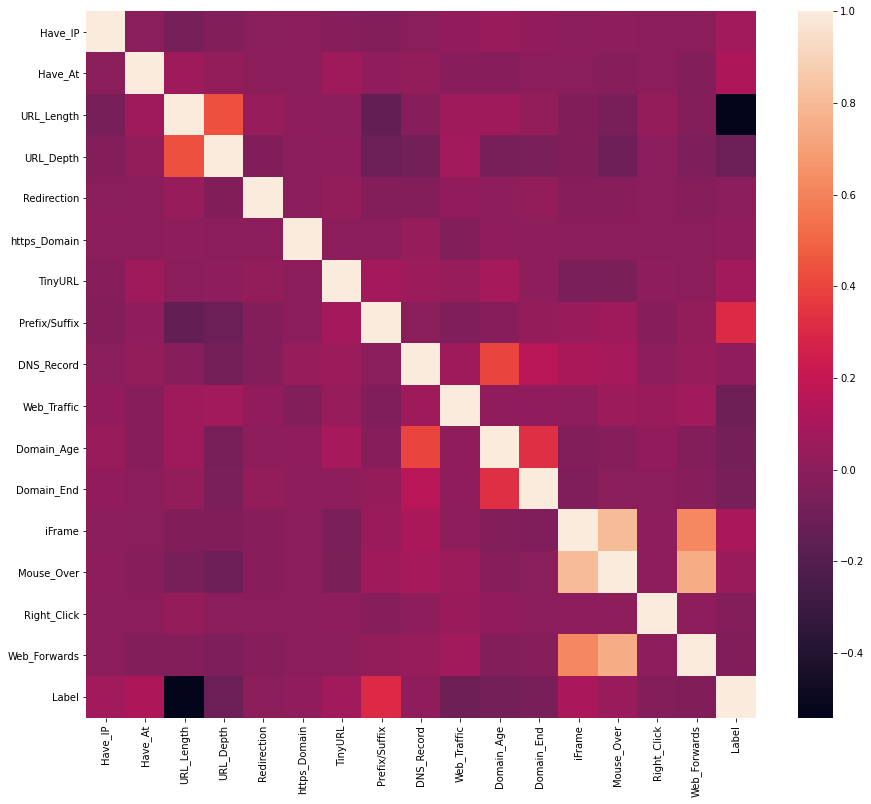

In [ ]:
#Correlation heatmap
##old
plt.figure(figsize=(15,13))
sns.heatmap(data0.corr())
plt.show()

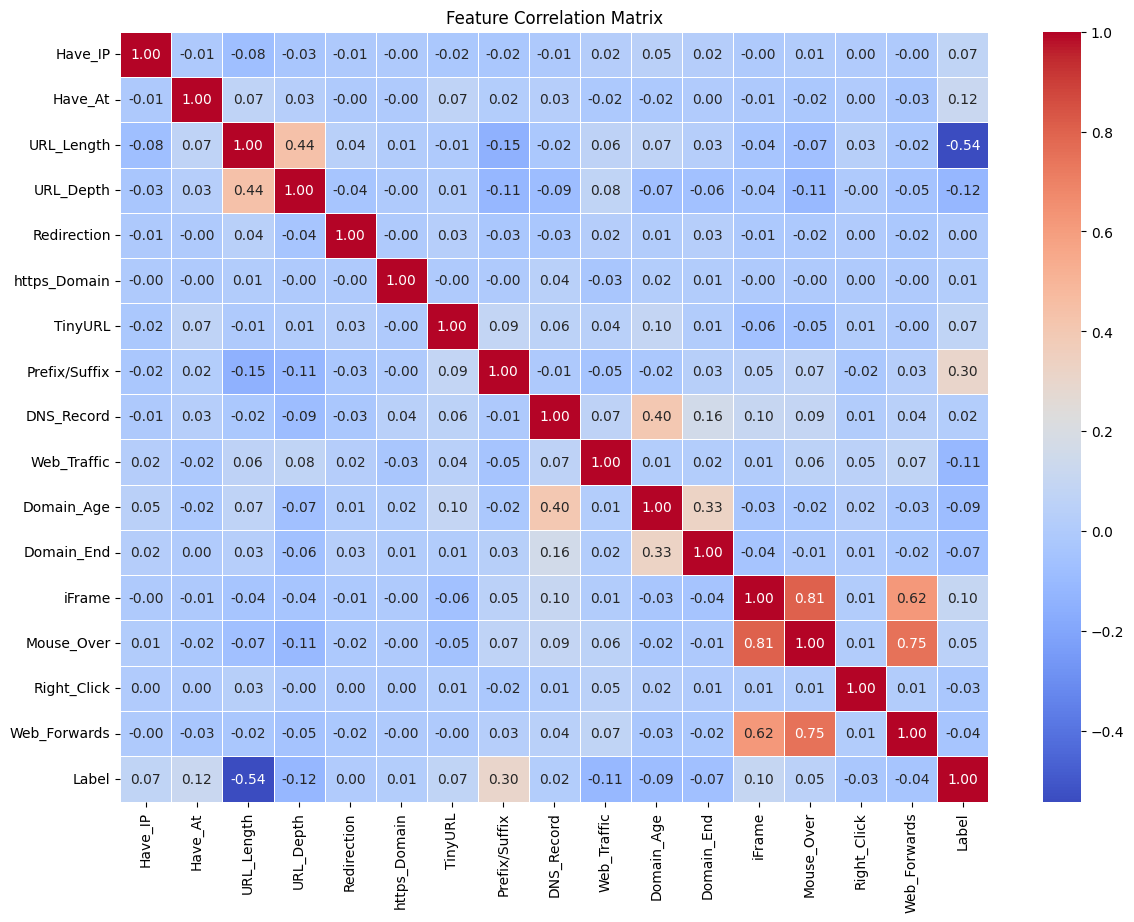

In [26]:
# Correlation Matrix
#new
corr = data0.drop("Domain", axis=1).corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")

plt.show()

### Correlation Analysis Summary *

<font color="red">Most features show weak correlations, indicating limited linear dependency between them.

<font color="red">However, a strong positive correlation (0.81) was observed between **iFrame** and **Mouse_Over**. In addition, **Mouse_Over** and **Web_Forwards** (0.75), as well as **iFrame** and **Web_Forwards** (0.62), also exhibit relatively strong correlations. This suggests that these suspicious behaviors often appear together in phishing websites.

<font color="red">Although these correlations indicate some redundancy, they are still meaningful from a cybersecurity perspective because phishing websites frequently combine multiple malicious techniques. Therefore, all features were retained for model training.Most features show weak correlations, indicating limited linear dependency between them.

<font color="red">However, a strong positive correlation (0.81) was observed between **iFrame** and **Mouse_Over**. In addition, **Mouse_Over** and **Web_Forwards** (0.75), as well as **iFrame** and **Web_Forwards** (0.62), also exhibit relatively strong correlations. This suggests that these suspicious behaviors often appear together in phishing websites.

<font color="red">Although these correlations indicate some redundancy, they are still meaningful from a cybersecurity perspective because phishing websites frequently combine multiple malicious techniques. Therefore, all features were retained for model training.

Label          0     1
URL_Length            
0              0  2266
1           5000  2734


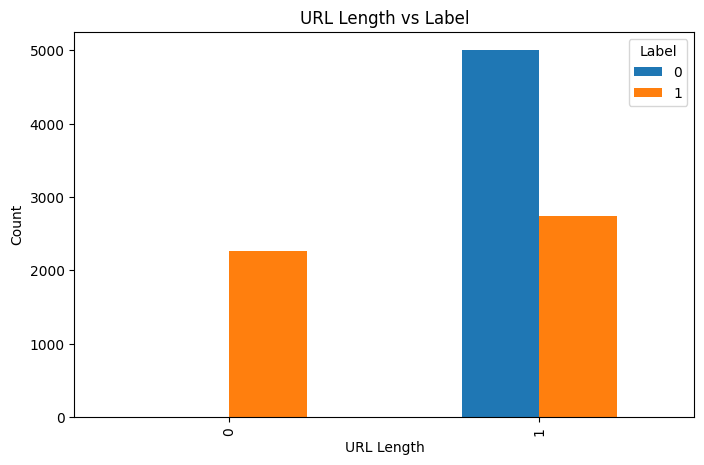

In [27]:
# Crosstab: URL Length vs Label

crosstab = pd.crosstab(data0["URL_Length"], data0["Label"])

print(crosstab)

crosstab.plot(kind="bar", figsize=(8,5))

plt.title("URL Length vs Label")
plt.xlabel("URL Length")
plt.ylabel("Count")
plt.show()

### Crosstab Analysis *

<font color="red">The crosstab compares the binary URL_Length feature with the target label.

<font color="red">The results show that URL_Length alone does not perfectly separate phishing and legitimate websites. While all legitimate websites belong to one category, phishing websites appear in both categories.

<font color="red">This suggests that URL_Length is informative but should be combined with additional features to achieve accurate phishing detection.

In [28]:
# GroupBy Analysis

group = data0.groupby("Label")["URL_Depth"].mean()

print(group)

Label
0    3.3268
1    2.8172
Name: URL_Depth, dtype: float64


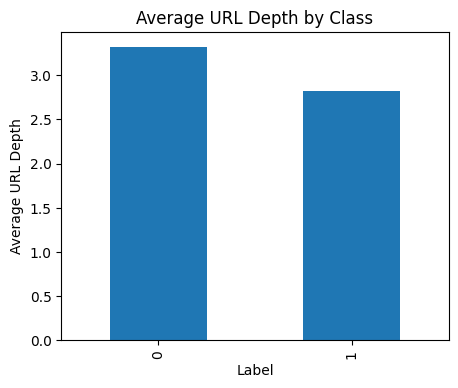

In [29]:
group.plot(kind="bar", figsize=(5,4))

plt.title("Average URL Depth by Class")
plt.ylabel("Average URL Depth")

plt.show()

### GroupBy Analysis *

<font color="red">The average URL depth differs between the two classes.

<font color="red">Legitimate websites have an average URL depth of approximately **3.33**, while phishing websites have an average depth of approximately **2.82**.

<font color="red">This indicates that URL depth alone is not a strong indicator of phishing. Instead, it should be combined with other features to improve the performance of the classification models.

# Feature Engineering Analysis *

<font color="red">Feature engineering is the process of transforming raw data into meaningful numerical features that can be used by machine learning algorithms.

<font color="red">In this project, the dataset has already undergone feature engineering before being released. The original URLs were analyzed, and several cybersecurity-related features were extracted from each website.

### Features Used *

The dataset contains the following extracted features:

- Have_IP
- Have_At
- URL_Length
- URL_Depth
- Redirection
- https_Domain
- TinyURL
- Prefix/Suffix
- DNS_Record
- Web_Traffic
- Domain_Age
- Domain_End
- iFrame
- Mouse_Over
- Right_Click
- Web_Forwards

The target variable is **Label**, where:
- 0 = Legitimate website
- 1 = Phishing website

### Encoding *

<font color="red">No additional encoding was required.

<font color="red">The original project already converted categorical cybersecurity characteristics into numerical values (mostly binary 0/1), making the dataset directly compatible with machine learning algorithms.

### Feature Scaling *

<font color="red">Feature scaling was not applied.

<font color="red">Most variables are binary (0 or 1), while URL_Depth contains relatively small integer values. Therefore, additional normalization or standardization was not considered necessary for the evaluated models.

### Feature Creation *

<font color="red">The original dataset consisted of website URLs. Before building the machine learning models, the original project extracted several cybersecurity-related features from each URL.

<font color="red">For example, instead of using the raw URL text, the project created features such as:

- Whether the URL contains an IP address (Have_IP)
- Whether it contains the '@' symbol (Have_At)
- URL length
- URL depth
- TinyURL usage
- Domain age
- DNS record availability
- iFrame usage
- Mouse-over behavior

<font color="red">These new features transformed raw website addresses into structured numerical data that can be used by machine learning algorithms.

### Feature Selection *

<font color="red">The Domain column was excluded from the analysis because it contains textual website names rather than numerical information useful for model training.

<font color="red">All remaining features were retained since each represents a different cybersecurity characteristic.

### Feature Redundancy *

<font color="red">The correlation analysis revealed strong relationships between several features, particularly:

- iFrame and Mouse_Over (0.81)
- Mouse_Over and Web_Forwards (0.75)
- iFrame and Web_Forwards (0.62)

<font color="red">These correlations suggest partial redundancy because these behaviors often occur together in phishing websites.

<font color="red">However, the features were retained because each captures a different aspect of malicious website behavior.

### Possible Additional Features *

<font color="red">The following features could further improve phishing detection:

- Number of subdomains
- Number of dots in the URL
- Presence of HTTPS certificate validation
- Number of digits in the URL
- Number of special characters
- URL entropy
- Suspicious keywords (login, verify, secure, update)

### Dimensionality Reduction *

<font color="red">Dimensionality reduction was not applied in this project.

<font color="red">The dataset contains a relatively small number of meaningful features, most of which represent important cybersecurity characteristics.

<font color="red">Since the feature space is already compact and interpretable, applying techniques such as Principal Component Analysis (PCA) was not considered necessary.

## **5. Data Preprocessing & EDA**
Here, we clean the data by applying data preprocesssing techniques and transform the data to use it in the models.

In [30]:
data0.describe()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
mean,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.00000,1.00000,1.000000,1.000000


The above obtained result shows that the most of the data is made of 0's & 1's except 'Domain' & 'URL_Depth' columns. The Domain column doesnt have any significance to the machine learning model training. So dropping the *'Domain'* column from the dataset.

In [31]:
#Dropping the Domain column
data = data0.drop(['Domain'], axis = 1).copy()

This leaves us with 16 features & a target column. The *'URL_Depth'* maximum value is 20. According to my understanding, there is no necessity to change this column.

In [33]:
#checking the data for null or missing values
data.isnull().sum()

,0
Have_IP,0
Have_At,0
URL_Length,0
URL_Depth,0
Redirection,0
https_Domain,0
TinyURL,0
Prefix/Suffix,0
DNS_Record,0
Web_Traffic,0


In the feature extraction file, the extracted features of legitmate & phishing url datasets are just concatenated without any shuffling. This resulted in top 5000 rows of legitimate url data & bottom 5000 of phishing url data.

To even out the distribution while splitting the data into training & testing sets, we need to shuffle it. This even evades the case of overfitting while model training.

In [34]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
1,0,0,1,2,0,0,0,0,0,1,0,0,0,0,1,0,0
2,0,0,1,6,0,0,0,0,0,0,0,1,0,0,1,0,1
3,0,0,1,3,0,0,0,0,0,1,0,1,1,1,1,1,1
4,0,0,1,6,0,0,0,0,0,1,0,1,0,0,1,0,1


From the above execution, it is clear that the data doesnot have any missing values.

By this, the data is throughly preprocessed & is ready for training.

## **6. Splitting the Data**

In [35]:
# Sepratating & assigning features and target columns to X & y
y = data['Label']
X = data.drop('Label',axis=1)
X.shape, y.shape

((10000, 16), (10000,))

In [36]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, random_state = 12)
X_train.shape, X_test.shape

((8000, 16), (2000, 16))

## **7. Machine Learning Models & Training**

From the dataset above, it is clear that this is a supervised machine learning task. There are two major types of supervised machine learning problems, called classification and regression.

This data set comes under classification problem, as the input URL is classified as phishing (1) or legitimate (0). The supervised machine learning models (classification) considered to train the dataset in this notebook are:
* Decision Tree
* Random Forest
* Multilayer Perceptrons
* XGBoost
* Autoencoder Neural Network
* Support Vector Machines

In [37]:
#importing packages
from sklearn.metrics import accuracy_score

In [38]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

### **7.1. Decision Tree Classifier**
 Decision trees are widely used models for classification and regression tasks. Essentially, they learn a hierarchy of if/else questions, leading to a decision. Learning a decision tree means learning the sequence of if/else questions that gets us to the true answer most quickly.

In the machine learning setting, these questions are called tests (not to be confused with the test set, which is the data we use to test to see how generalizable our model is). To build a tree, the algorithm searches over all possible tests and finds the one that is most informative about the target variable.

In [39]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# instantiate the model
tree = DecisionTreeClassifier(max_depth = 5)
# fit the model
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [40]:
#predicting the target value from the model for the samples
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

**Performance Evaluation:**

In [41]:
#computing the accuracy of the model performance
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)

print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))

Decision Tree: Accuracy on training Data: 0.811
Decision Tree: Accuracy on test Data: 0.821


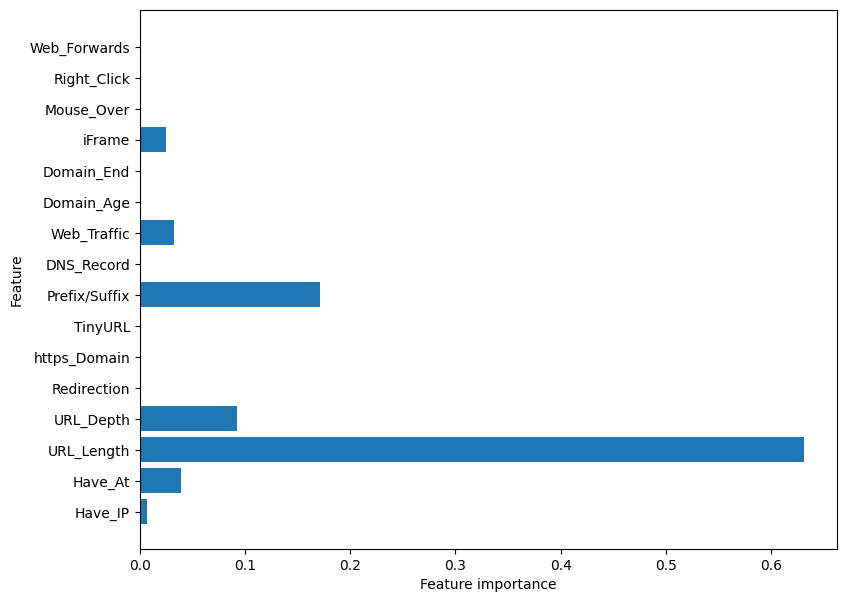

In [42]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

**Storing the results:**

In [47]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

##I add:

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
    roc_auc_score
)

### **7.2. Random Forest Classifier**
Random forests for regression and classification are currently among the most widely used machine learning methods.A random forest is essentially a collection of decision trees, where each tree is slightly different from the others. The idea behind random forests is that each tree might do a relatively good job of predicting, but will likely overfit on part of the data.

If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging their results. To build a random forest model, you need to decide on the number of trees to build (the n_estimators parameter of RandomForestRegressor or RandomForestClassifier). They are very powerful, often work well without heavy tuning of the parameters, and don’t require scaling of the data.

In [49]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5)

# fit the model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5)

In [50]:
#predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

**Performance Evaluation:**

In [51]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random forest: Accuracy on training Data: 0.816
Random forest: Accuracy on test Data: 0.824


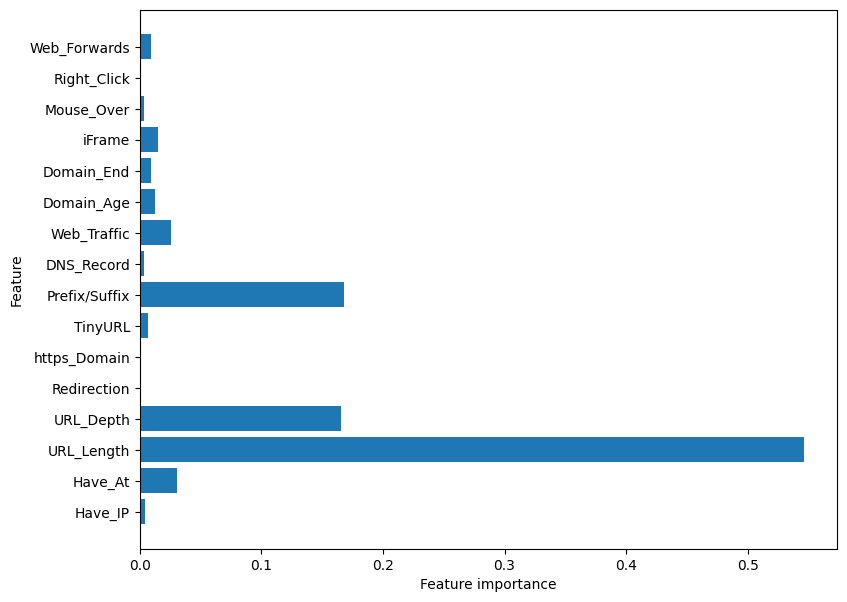

In [52]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [54]:
# Evaluation Metrics

print("Accuracy :", accuracy_score(y_test, y_test_forest))
print("Precision:", precision_score(y_test, y_test_forest))
print("Recall   :", recall_score(y_test, y_test_forest))
print("F1 Score :", f1_score(y_test, y_test_forest))
print("ROC AUC  :", roc_auc_score(y_test, y_test_forest))
print("MCC      :", matthews_corrcoef(y_test, y_test_forest))

Accuracy : 0.8235
Precision: 0.9939301972685888
Recall   : 0.6523904382470119
F1 Score : 0.7877330126277812
ROC AUC  : 0.8241871869949919
MCC      : 0.689708012121632


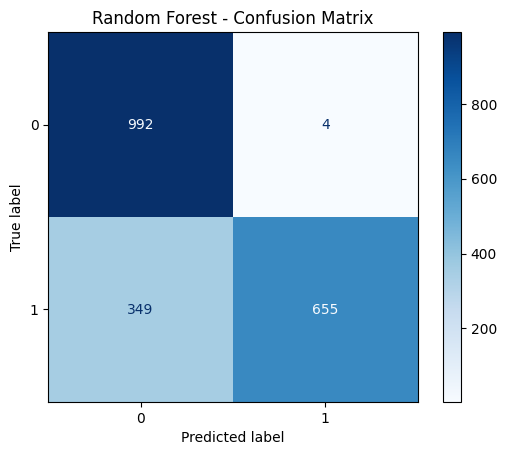

In [55]:
cm = confusion_matrix(y_test, y_test_forest)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

**Storing the results:**

In [56]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

### **7.3. Multilayer Perceptrons (MLPs): Deep Learning**
Multilayer perceptrons (MLPs) are also known as (vanilla) feed-forward neural networks, or sometimes just neural networks. Multilayer perceptrons can be applied for both classification and regression problems.

MLPs can be viewed as generalizations of linear models that perform multiple stages of processing to come to a decision.

In [57]:
# Multilayer Perceptrons model
from sklearn.neural_network import MLPClassifier

# instantiate the model
mlp = MLPClassifier(alpha=0.001, hidden_layer_sizes=([100,100,100]))

# fit the model
mlp.fit(X_train, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=[100, 100, 100])

In [58]:
#predicting the target value from the model for the samples
y_test_mlp = mlp.predict(X_test)
y_train_mlp = mlp.predict(X_train)

**Performance Evaluation:**

In [59]:
#computing the accuracy of the model performance
acc_train_mlp = accuracy_score(y_train,y_train_mlp)
acc_test_mlp = accuracy_score(y_test,y_test_mlp)

print("Multilayer Perceptrons: Accuracy on training Data: {:.3f}".format(acc_train_mlp))
print("Multilayer Perceptrons: Accuracy on test Data: {:.3f}".format(acc_test_mlp))

Multilayer Perceptrons: Accuracy on training Data: 0.864
Multilayer Perceptrons: Accuracy on test Data: 0.872


In [61]:
# Evaluation Metrics

print("Accuracy :", accuracy_score(y_test, y_test_mlp))
print("Precision:", precision_score(y_test, y_test_mlp))
print("Recall   :", recall_score(y_test, y_test_mlp))
print("F1 Score :", f1_score(y_test, y_test_mlp))
print("ROC AUC  :", roc_auc_score(y_test, y_test_mlp))
print("MCC      :", matthews_corrcoef(y_test, y_test_mlp))

Accuracy : 0.872
Precision: 0.9269406392694064
Recall   : 0.8087649402390438
F1 Score : 0.8638297872340426
ROC AUC  : 0.872253956063297
MCC      : 0.7502925504401053


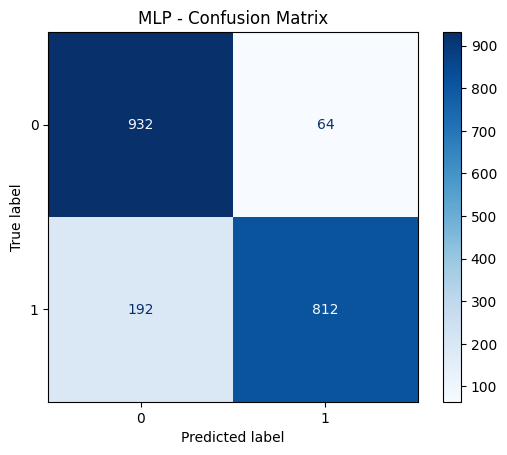

In [62]:
cm = confusion_matrix(y_test, y_test_mlp)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("MLP - Confusion Matrix")
plt.show()

**Storing the results:**

In [60]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

### **7.4. XGBoost Classifier**
XGBoost is one of the most popular machine learning algorithms these days. XGBoost stands for eXtreme Gradient Boosting. Regardless of the type of prediction task at hand; regression or classification. XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.

In [63]:
#XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)
#fit the model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [64]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

**Performance Evaluation:**

In [65]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.865
XGBoost : Accuracy on test Data: 0.870


In [67]:
# Evaluation Metrics

print("Accuracy :", accuracy_score(y_test, y_test_xgb))
print("Precision:", precision_score(y_test, y_test_xgb))
print("Recall   :", recall_score(y_test, y_test_xgb))
print("F1 Score :", f1_score(y_test, y_test_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_test_xgb))
print("MCC      :", matthews_corrcoef(y_test, y_test_xgb))

Accuracy : 0.87
Precision: 0.9335664335664335
Recall   : 0.797808764940239
F1 Score : 0.8603651987110634
ROC AUC  : 0.8702899246387941
MCC      : 0.7481552377425683


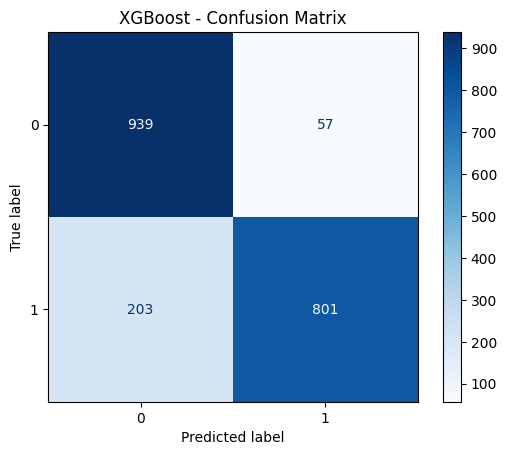

In [68]:
cm = confusion_matrix(y_test, y_test_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()

**Storing the results:**

In [66]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

### **7.5. Autoencoder Neural Network**
An auto encoder is a neural network that has the same number of input neurons as it does outputs. The hidden layers of the neural network will have fewer neurons than the input/output neurons. Because there are fewer neurons, the auto-encoder must learn to encode the input to the fewer hidden neurons. The predictors (x) and output (y) are exactly the same in an auto encoder.

In [69]:
#importing required packages
import keras
from keras.layers import Input, Dense
from keras import regularizers
import tensorflow as tf
from keras.models import Model
from sklearn import metrics

In [71]:
#building autoencoder model

input_dim = X_train.shape[1]
encoding_dim = input_dim

input_layer = Input(shape=(input_dim, ))
encoder = Dense(encoding_dim, activation="relu",
                activity_regularizer=regularizers.l1(10e-4))(input_layer)
encoder = Dense(int(encoding_dim), activation="relu")(encoder)

encoder = Dense(int(encoding_dim-2), activation="relu")(encoder)
code = Dense(int(encoding_dim-4), activation='relu')(encoder)
decoder = Dense(int(encoding_dim-2), activation='relu')(code)

decoder = Dense(int(encoding_dim), activation='relu')(encoder)
decoder = Dense(input_dim, activation='relu')(decoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           238 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294 (5.05 KB)

 Trainable params: 1,294 (5.05 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
#compiling the model
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

#Training the model
history = autoencoder.fit(X_train, X_train, epochs=10, batch_size=64, shuffle=True, validation_split=0.2)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0202 - loss: 2.4495 - val_accuracy: 0.0319 - val_loss: 1.8115
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0250 - loss: 1.6599 - val_accuracy: 0.0319 - val_loss: 1.2347
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0352 - loss: 0.0520 - val_accuracy: 0.1431 - val_loss: -1.0633
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3778 - loss: -1.1956 - val_accuracy: 0.5744 - val_loss: -1.1408
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6806 - loss: -1.2235 - val_accuracy: 0.8325 - val_loss: -1.1379
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8270 - loss: -1.2404 - val_accuracy: 0.8037 - val_loss: -1.1719
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7430 - loss: -1.2854 - val_accuracy: 0.6762 - val_loss: -1.2187
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6489 - loss: -1.3272 - val_ac

**Performance Evaluation:**

In [74]:
acc_train_auto = autoencoder.evaluate(X_train, X_train)[1]
acc_test_auto = autoencoder.evaluate(X_test, X_test)[1]

print('\nAutoencoder: Accuracy on training Data: {:.3f}' .format(acc_train_auto))
print('Autoencoder: Accuracy on test Data: {:.3f}' .format(acc_test_auto))

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5025 - loss: -1.7017
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4965 - loss: -1.6419

Autoencoder: Accuracy on training Data: 0.502
Autoencoder: Accuracy on test Data: 0.496


**Storing the results:**

In [75]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('AutoEncoder', acc_train_auto, acc_test_auto)

### **7.6. Support Vector Machines**

In machine learning, support-vector machines (SVMs, also support-vector networks) are supervised learning models with associated learning algorithms that analyze data used for classification and regression analysis. Given a set of training examples, each marked as belonging to one or the other of two categories, an SVM training algorithm builds a model that assigns new examples to one category or the other, making it a non-probabilistic binary linear classifier.

In [76]:
#Support vector machine model
from sklearn.svm import SVC

# instantiate the model
svm = SVC(kernel='linear', C=1.0, random_state=12)
#fit the model
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=12)

In [77]:
#predicting the target value from the model for the samples
y_test_svm = svm.predict(X_test)
y_train_svm = svm.predict(X_train)

**Performance Evaluation:**

In [78]:
#computing the accuracy of the model performance
acc_train_svm = accuracy_score(y_train,y_train_svm)
acc_test_svm = accuracy_score(y_test,y_test_svm)

print("SVM: Accuracy on training Data: {:.3f}".format(acc_train_svm))
print("SVM : Accuracy on test Data: {:.3f}".format(acc_test_svm))

SVM: Accuracy on training Data: 0.800
SVM : Accuracy on test Data: 0.808


In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, matthews_corrcoef

print("Accuracy :", accuracy_score(y_test, y_test_svm))
print("Precision:", precision_score(y_test, y_test_svm))
print("Recall   :", recall_score(y_test, y_test_svm))
print("F1 Score :", f1_score(y_test, y_test_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_test_svm))
print("MCC      :", matthews_corrcoef(y_test, y_test_svm))

Accuracy : 0.8085
Precision: 0.9726027397260274
Recall   : 0.6364541832669323
F1 Score : 0.769416014449127
ROC AUC  : 0.8091909470551529
MCC      : 0.6583132551220332


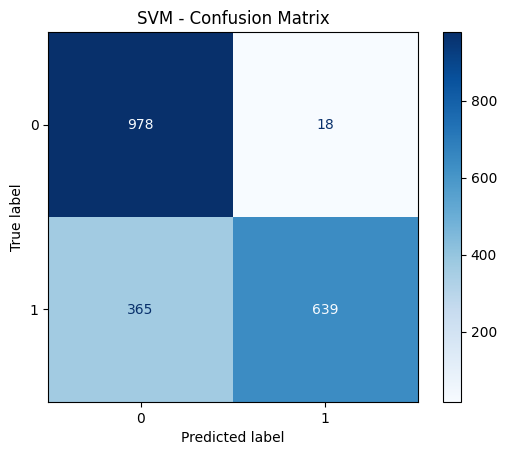

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("SVM - Confusion Matrix")
plt.show()

**Storing the results:**

In [79]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('SVM', acc_train_svm, acc_test_svm)

## **8. Comparision of Models**
To compare the models performance, a dataframe is created. The columns of this dataframe are the lists created to store the results of the model.

In [87]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,Decision Tree,0.811,0.821
1,Decision Tree,0.811,0.821
2,Random Forest,0.816,0.824
3,Random Forest,0.816,0.824
4,Multilayer Perceptrons,0.864,0.872
5,XGBoost,0.865,0.870
6,AutoEncoder,0.502,0.496
7,SVM,0.800,0.808


In [88]:
#Sorting the datafram on accuracy
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
4,Multilayer Perceptrons,0.864,0.872
5,XGBoost,0.865,0.870
2,Random Forest,0.816,0.824
3,Random Forest,0.816,0.824
0,Decision Tree,0.811,0.821
1,Decision Tree,0.811,0.821
7,SVM,0.800,0.808
6,AutoEncoder,0.502,0.496


## Model Performance Comparison *

The following table summarizes the performance of all machine learning models using the evaluation metrics Accuracy, Precision, Recall, F1-Score, ROC AUC, and MCC.

In [89]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "MLP", "XGBoost", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_test_tree),
        accuracy_score(y_test, y_test_forest),
        accuracy_score(y_test, y_test_mlp),
        accuracy_score(y_test, y_test_xgb),
        accuracy_score(y_test, y_test_svm)
    ],
    "Precision": [
        precision_score(y_test, y_test_tree),
        precision_score(y_test, y_test_forest),
        precision_score(y_test, y_test_mlp),
        precision_score(y_test, y_test_xgb),
        precision_score(y_test, y_test_svm)
    ],
    "Recall": [
        recall_score(y_test, y_test_tree),
        recall_score(y_test, y_test_forest),
        recall_score(y_test, y_test_mlp),
        recall_score(y_test, y_test_xgb),
        recall_score(y_test, y_test_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_test_tree),
        f1_score(y_test, y_test_forest),
        f1_score(y_test, y_test_mlp),
        f1_score(y_test, y_test_xgb),
        f1_score(y_test, y_test_svm)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_test_tree),
        roc_auc_score(y_test, y_test_forest),
        roc_auc_score(y_test, y_test_mlp),
        roc_auc_score(y_test, y_test_xgb),
        roc_auc_score(y_test, y_test_svm)
    ],
    "MCC": [
        matthews_corrcoef(y_test, y_test_tree),
        matthews_corrcoef(y_test, y_test_forest),
        matthews_corrcoef(y_test, y_test_mlp),
        matthews_corrcoef(y_test, y_test_xgb),
        matthews_corrcoef(y_test, y_test_svm)
    ]
})

results = results.round(3)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,MCC
0,Decision Tree,0.820,0.981,0.655,0.786,0.821,0.680
1,Random Forest,0.824,0.994,0.652,0.788,0.824,0.690
2,MLP,0.872,0.927,0.809,0.864,0.872,0.750
3,XGBoost,0.870,0.934,0.798,0.860,0.870,0.748
4,SVM,0.808,0.973,0.636,0.769,0.809,0.658


## Accuracy Comparison *

The following figure compares the classification accuracy achieved by each machine learning model.

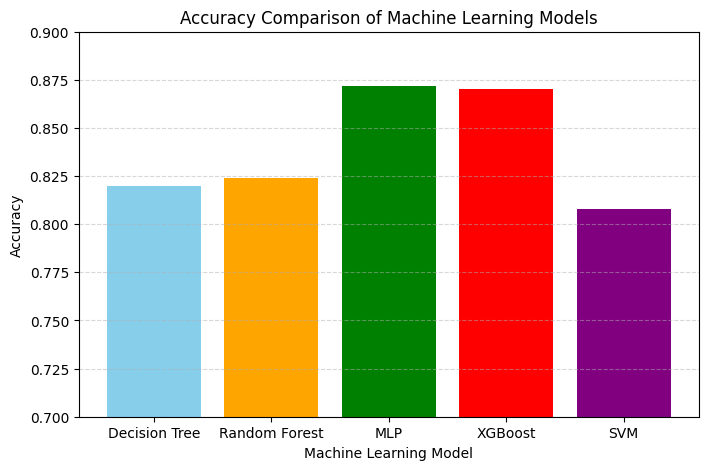

In [90]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"],
        results["Accuracy"],
        color=["skyblue","orange","green","red","purple"])

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0.7,0.9)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Best Model Selection *

The model with the highest overall performance is selected based on the evaluation metrics, with particular emphasis on Accuracy and F1-Score.

In [91]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model          MLP
Accuracy     0.872
Precision    0.927
Recall       0.809
F1 Score     0.864
ROC AUC      0.872
MCC           0.75
Name: 2, dtype: object


# Results Discussion *
<font color="red">In our implementation, the Multilayer Perceptron achieved the highest test accuracy (87.2%), while the original notebook reported XGBoost as the best model. The difference is very small (0.2%) and is likely due to differences in software versions or random initialization during training.

# Error Analysis *

<font color="red">The confusion matrices show that all models made both false positive and false negative predictions.

<font color="red">False positives classify legitimate websites as phishing, which may inconvenience users.

<font color="red">False negatives classify phishing websites as legitimate. In cybersecurity, false negatives are more dangerous because they may allow phishing attacks to reach users.

<font color="red">The MLP model achieved the highest Recall, meaning it detected more phishing websites than the other models while maintaining high overall performance.

##Original notebook results are shown below.****

For the above comparision, it is clear that the XGBoost Classifier works well with this dataset.

So, saving the model for future use.

In [92]:
# save XGBoost model to file
import pickle
pickle.dump(xgb, open("XGBoostClassifier.pickle.dat", "wb"))

**Testing the saved model:**

In [93]:
# load model from file
loaded_model = pickle.load(open("XGBoostClassifier.pickle.dat", "rb"))
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## **9. References**
* https://blog.keras.io/building-autoencoders-in-keras.html
* https://en.wikipedia.org/wiki/Autoencoder
* https://mc.ai/a-beginners-guide-to-build-stacked-autoencoder-and-tying-weights-with-it/
* https://github.com/shreyagopal/t81_558_deep_learning/blob/master/t81_558_class_14_03_anomaly.ipynb
* https://machinelearningmastery.com/save-gradient-boosting-models-xgboost-python/